In [ ]:
# Post Process Grid Search

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import parallel_coordinates

## Read and Clean data

In [ ]:
# STAGE 2: MANURE & BASELINE
# read
ma_gs_fp = # path to stage 2 grid search results
ma_gs = pd.read_csv(ma_gs_fp)

# Stage 2 (ma & gs) relevant columns
stage2_cols = ['test_number', 'param_n_fert_base',	'param_p_fert_base', 'param_n_fert_ma',	'param_p_fert_ma', 'param_phu_wheat','param_pec_ma', 'param_manure_incorp','base_WB_error','base_Crop_Yield', 'base_ET_per', 'base_WYLD_per', 'ma_USLEt_ha', 'ma_MUSLEt_ha', 'ma_Nkg_ha', 'ma_Pkg_ha']

# clean data
ma_gs_df = ma_gs[stage2_cols]
ma_gs_df['base_WB_error_abs'] = ma_gs_df['base_WB_error'].abs()

# STAGE 3: NO TILL & BASELINE
nt_gs_fp = # path to stage 3 grid search results
nt_gs = pd.read_csv(nt_gs_fp)

# Stage 3 (nt & gs) relevant columns
stage3_cols = ['test_number', 'param_n_fert_base',	'param_p_fert_base', 'param_n_fert_nt',	'param_p_fert_nt'	,'param_phu_wheat', 'param_pec_nt','param_residue','base_WB_error','base_Crop_Yield', 'base_ET_per', 'base_WYLD_per', 'nt_USLEt_ha', 'nt_MUSLEt_ha', 'nt_Nkg_ha', 'nt_Pkg_ha']

# clean data
nt_gs_df = nt_gs[stage3_cols]
nt_gs_df['base_WB_error_abs'] = nt_gs_df['base_WB_error'].abs()

# NOTE: CC (cover crop) stage intentionally omitted from this notebook.
# Per project convention, CC is only run for corn and soy (this is wheat)

ma_gs_subset = ma_gs_df.copy()
nt_gs_subset = nt_gs_df.copy()


## Set Objectives

In [ ]:
'''
Objective / deviation definitions for THIS run: Valley & Ridge, wheat

CC is not applicable here: per project convention, cover crop (CC) is only
run for corn and soy, so that stage is skipped entirely for wheat.

Values below for other region/crop combinations are preserved in
REFERENCE_VALUES at the bottom of this cell for provenance only. They were
never live in this run and have NOT been re-verified -- confirm against the
actual grid search output for that combination before reusing.
'''
# Manure (MA) stage 
range_only_ma = {
    'base_WYLD_per': (37, 60),
    'base_ET_per': (40, 64),
}
for metric, (lower, upper) in range_only_ma.items():
    ma_gs_subset[f'{metric}_dev'] = ma_gs_subset[metric].apply(
        lambda x: 0 if lower <= x <= upper else min(abs(x - lower), abs(x - upper))
    )

n_target_ma = 8
ma_gs_subset['ma_Nkg_ha_dev'] = ((n_target_ma - ma_gs_subset['ma_Nkg_ha']).abs() / n_target_ma) * 100
ma_gs_subset['ma_MUSLEt_ha_dev'] = ma_gs_subset['ma_MUSLEt_ha'].abs()
ma_gs_subset['base_WB_error_dev'] = ma_gs_subset['base_WB_error'].abs()

max_yield_ma = ma_gs_subset['base_Crop_Yield'].max()
ma_gs_subset['base_Crop_Yield_dev'] = ((max_yield_ma - ma_gs_subset['base_Crop_Yield']).abs() / max_yield_ma) * 100


objectives_ma = {
    'ma_Nkg_ha_dev': 'min',
    'ma_Pkg_ha_dev': 'min',
    'ma_MUSLEt_ha_dev': 'min',
    'base_Crop_Yield_dev': 'min',
}

# No-till (NT) stage
range_only_nt = {
    'base_WYLD_per': (37, 60),
    'base_ET_per': (40, 64),
    'nt_Pkg_ha': (49, 57),
}
for metric, (lower, upper) in range_only_nt.items():
    nt_gs_subset[f'{metric}_dev'] = nt_gs_subset[metric].apply(
        lambda x: 0 if lower <= x <= upper else min(abs(x - lower), abs(x - upper))
    )

n_target_nt = 10
y_target_nt = 41
nt_gs_subset['nt_Nkg_ha_dev'] = ((n_target_nt - nt_gs_subset['nt_Nkg_ha']).abs() / n_target_nt) * 100
nt_gs_subset['nt_MUSLEt_ha_dev'] = ((y_target_nt - nt_gs_subset['nt_MUSLEt_ha']).abs() / y_target_nt) * 100
nt_gs_subset['base_WB_error_dev'] = nt_gs_subset['base_WB_error'].abs()

# Same max-observed-yield approach as MA above.
max_yield_nt = nt_gs_subset['base_Crop_Yield'].max()
nt_gs_subset['base_Crop_Yield_dev'] = ((max_yield_nt - nt_gs_subset['base_Crop_Yield']).abs() / max_yield_nt) * 100

objectives_nt = {
    'nt_Nkg_ha_dev': 'min',
    'nt_Pkg_ha_dev': 'min',
    'nt_MUSLEt_ha_dev': 'min',
    'base_Crop_Yield_dev': 'min',
}

ma_gs_subset['avg_dev'] = ma_gs_subset[list(objectives_ma.keys())].mean(axis=1)
nt_gs_subset['avg_dev'] = nt_gs_subset[list(objectives_nt.keys())].mean(axis=1)


# BASED ON CBP CAST MODEL

REFERENCE_VALUES = {
    ('a', 'row_crop'):  {'wyld_range': (45, 60), 'et_range': (40, 55), 'ma_Pkg_ha_range': (12, 24)},
    ('a', 'hay'):       {'wyld_range': (44, 59), 'et_range': (41, 57)},
    ('p', 'row_crop'):  {'wyld_range': (30, 38), 'et_range': (63, 70), 'ma_Pkg_ha_range': (12, 24), 'nt_Pkg_ha_range': (58, 60)},
    ('p', 'hay'):       {'wyld_range': (28, 37), 'et_range': (64, 72)},
    ('cp', 'row_crop'): {'wyld_range': (30, 41), 'et_range': (59, 70), 'nt_Pkg_ha_range': (16, 35)},
    ('cp', 'hay'):      {'wyld_range': (28, 39.5), 'et_range': (61, 72)},
    'crop_yield_targets_superseded': {
        ('a', 'soy'): 2, ('a', 'corn'): 3.4, ('a', 'hay'): 5.7,
        ('p', 'soy'): [1.1, 2.5], ('p', 'corn'): 8.2, ('p', 'hay'): 7.8,
        ('vr', 'soy'): 3.9, ('vr', 'corn'): 4.6, ('vr', 'wheat'): [1.1, 3.2],
        ('cp', 'soy'): 4, ('cp', 'corn'): 5.1, ('cp', 'hay'): 6.3,
    },
}


## Visualize

### Plot: Parallel Coordinates

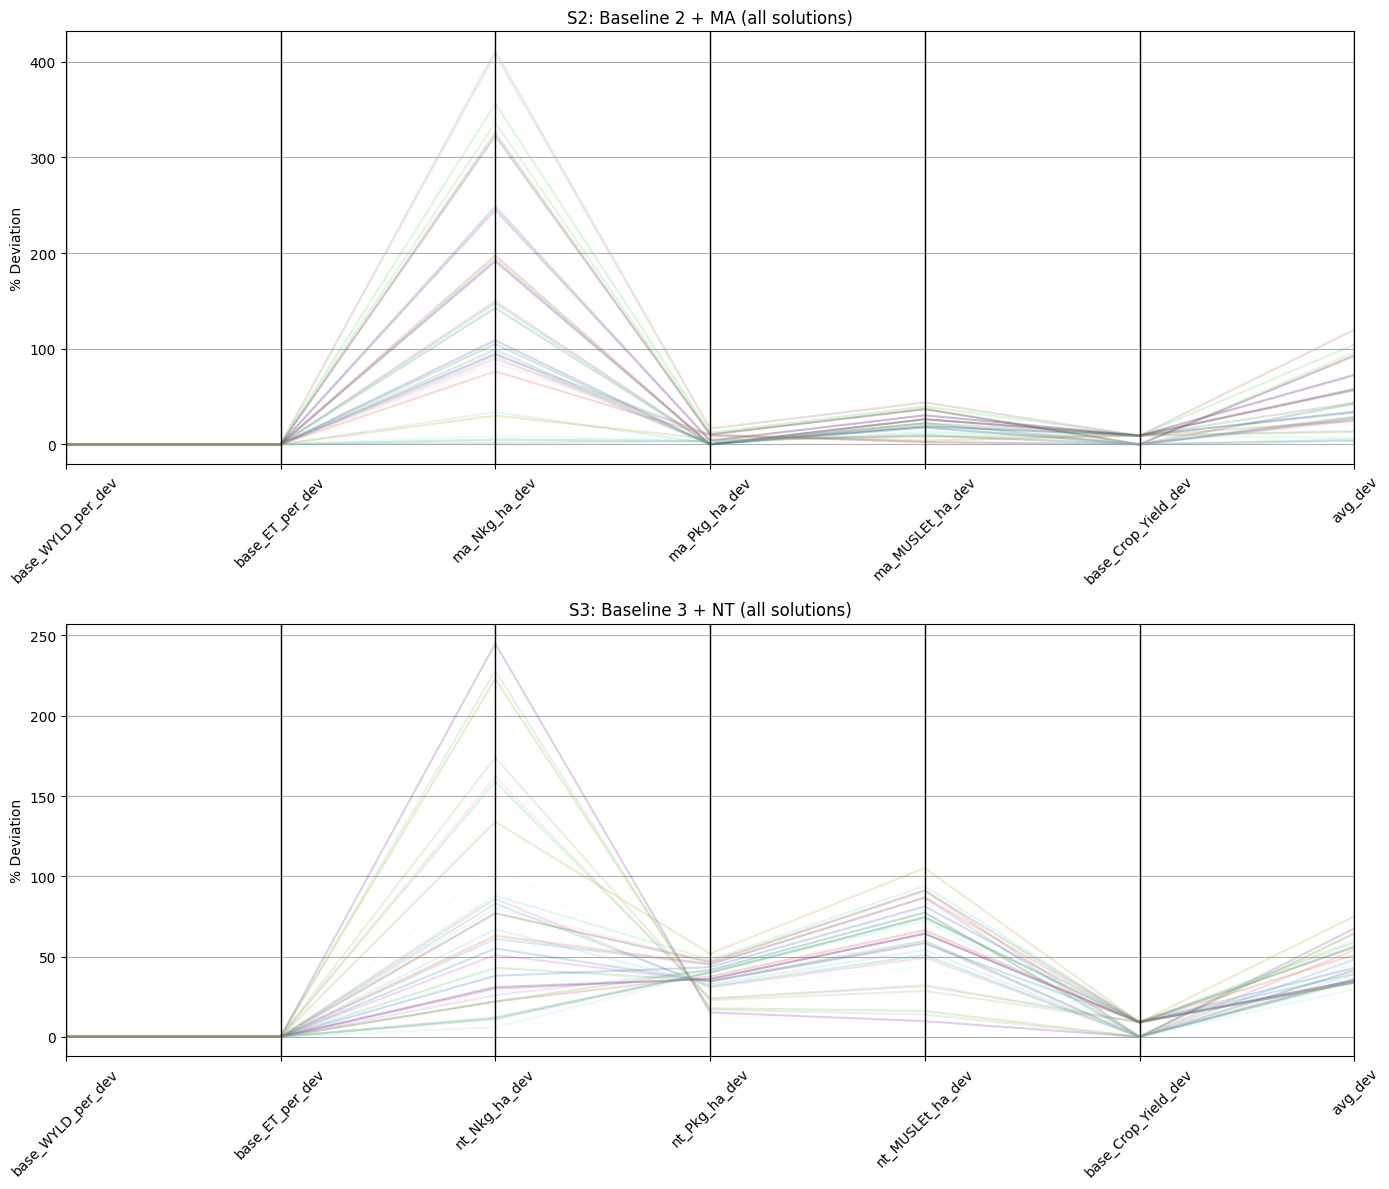

In [269]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# CC
# plot_df_cc = cc_gs_subset[obj_cols_cc + ['avg_dev']].copy()
# plot_df_cc['solution'] = range(len(plot_df_cc))
# parallel_coordinates(plot_df_cc, 'solution', alpha=0.2, ax=axes[2])
# axes[2].set_title('S1: Baseline 1 + CC (all solutions)')
# axes[2].set_ylabel('% Deviation')
# axes[2].legend().remove()
# axes[2].tick_params(axis='x', rotation=45)

# MA
plot_df_ma = ma_gs_subset[obj_cols_ma + ['avg_dev']].copy()
plot_df_ma['solution'] = range(len(plot_df_ma))
parallel_coordinates(plot_df_ma, 'solution', alpha=0.2, ax=axes[0])
axes[0].set_title('S2: Baseline 2 + MA (all solutions)')
axes[0].set_ylabel('% Deviation')
axes[0].legend().remove()
axes[0].tick_params(axis='x', rotation=45)

# NT
plot_df_nt = nt_gs_subset[obj_cols_nt + ['avg_dev']].copy()
plot_df_nt['solution'] = range(len(plot_df_nt))
parallel_coordinates(plot_df_nt, 'solution', alpha=0.2, ax=axes[1])
axes[1].set_title('S3: Baseline 3 + NT (all solutions)')
axes[1].set_ylabel('% Deviation')
axes[1].legend().remove()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('parallel_coordinates_all.png', dpi=300)
plt.show()

### Plot: Boxplot

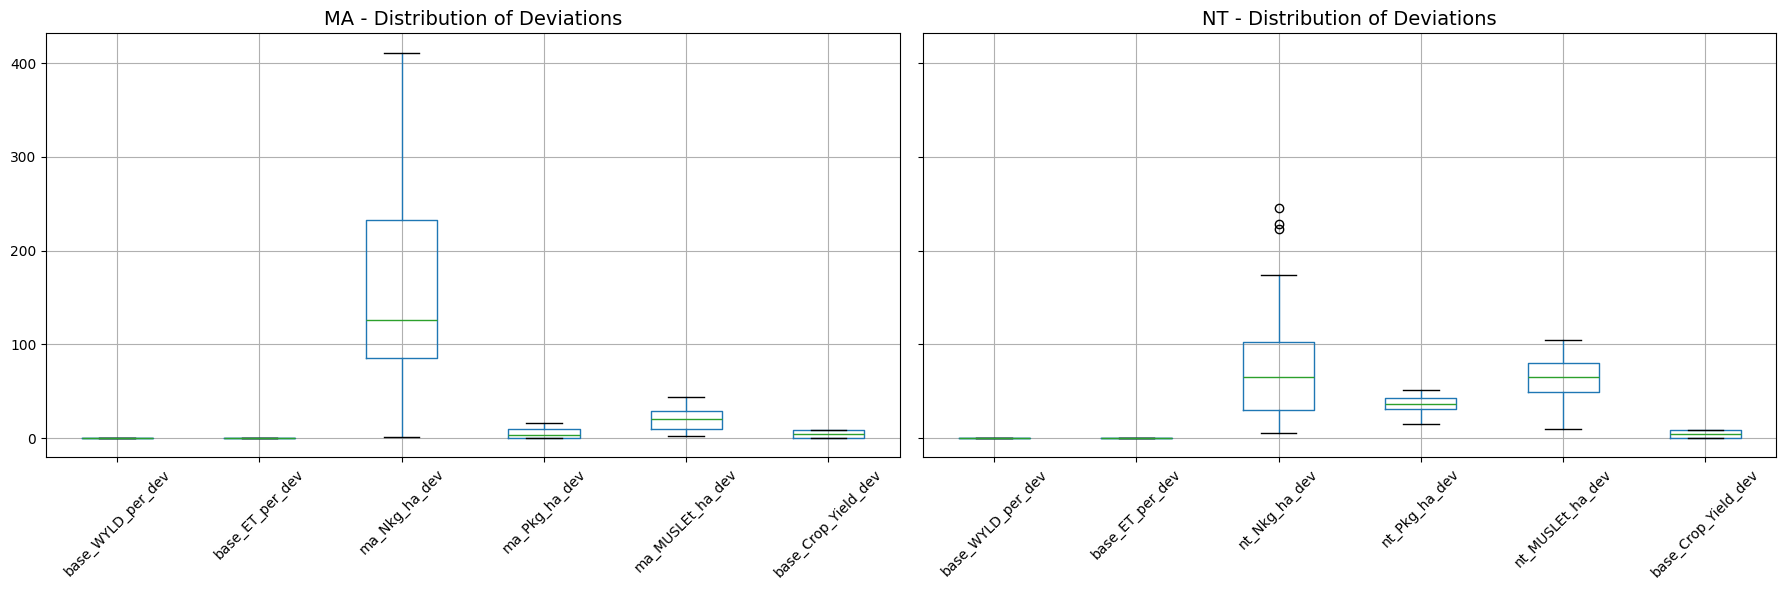

In [270]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

# CC
# cc_gs_subset[obj_cols_cc].boxplot(ax=axes[2])
# axes[2].set_title('CC - Distribution of Deviations', fontsize=14)
# axes[2].set_ylabel('Deviation (%)')
# axes[2].tick_params(axis='x', rotation=45)

# MA
ma_gs_subset[obj_cols_ma].boxplot(ax=axes[0])
axes[0].set_title('MA - Distribution of Deviations', fontsize=14)
axes[0].tick_params(axis='x', rotation=45)

# NT
nt_gs_subset[obj_cols_nt].boxplot(ax=axes[1])
axes[1].set_title('NT - Distribution of Deviations', fontsize=14)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('boxplots_all.png', dpi=300)
plt.show()

### Plot: Histogram

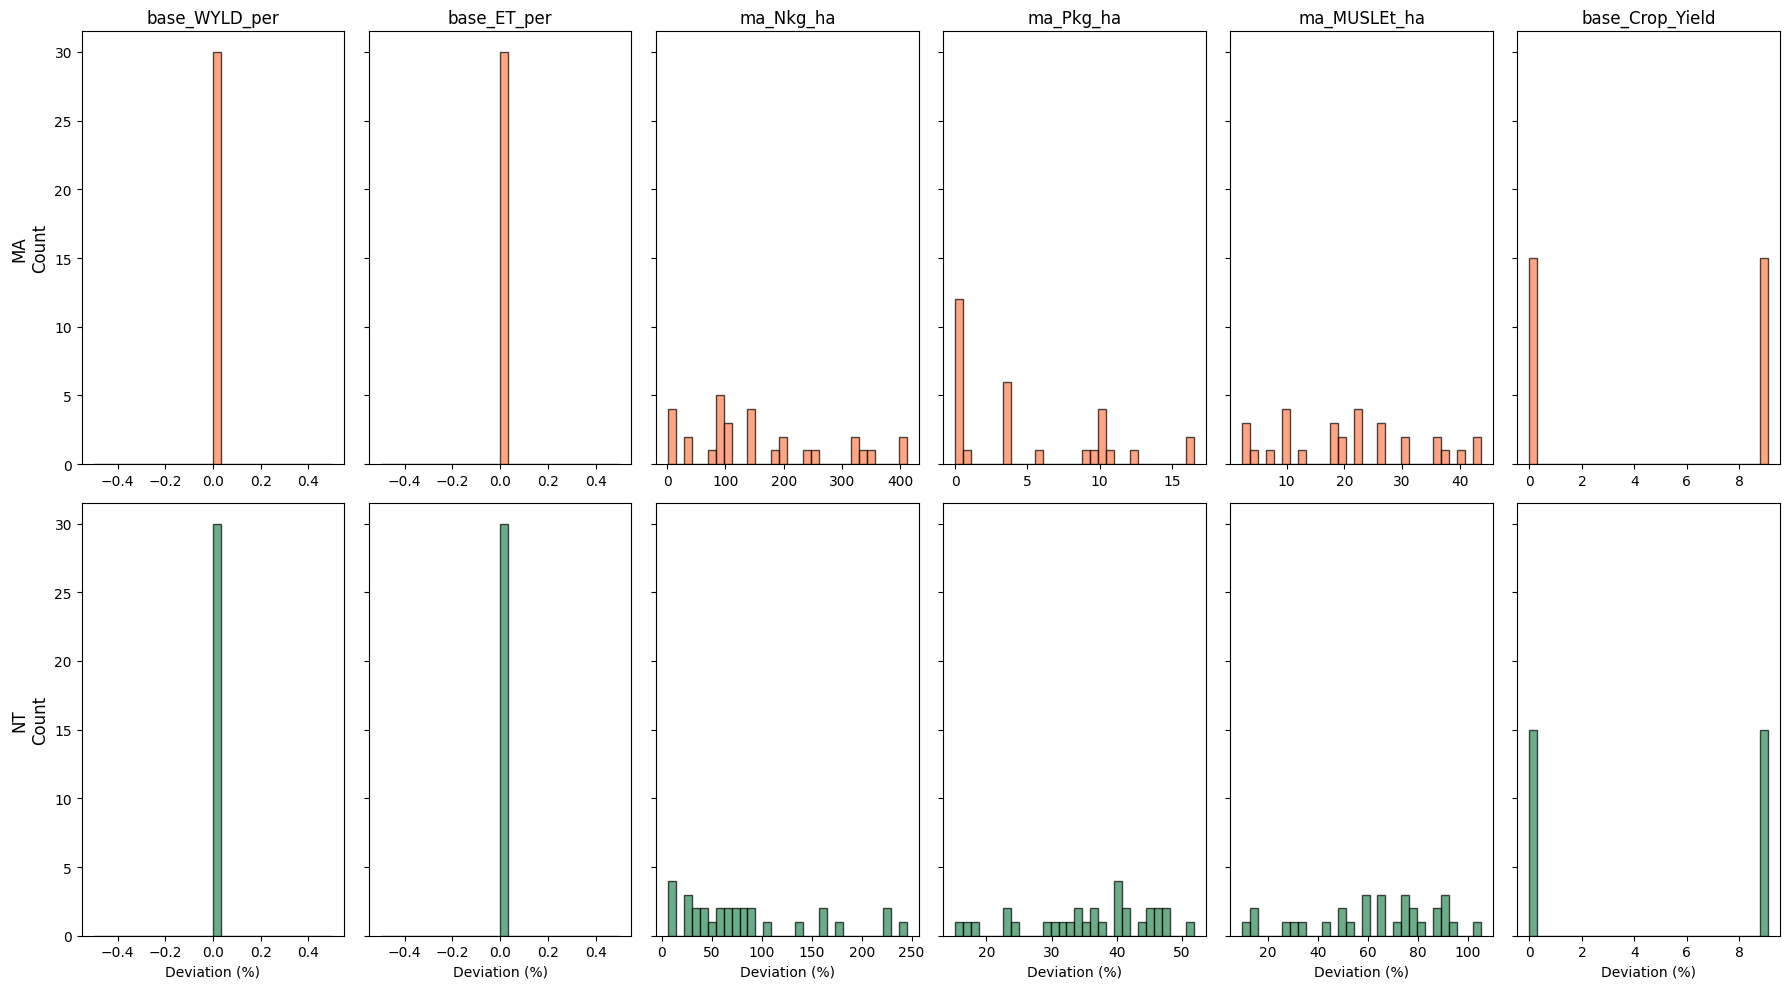

In [271]:
fig, axes = plt.subplots(2, len(obj_cols_ma), figsize=(18, 10), sharey='row')

# # # CC
# for i, obj in enumerate(obj_cols_cc):
#     axes[2, i].hist(cc_gs_subset[obj], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
#     axes[2, i].set_title(obj.replace('cc_', ''))

# MA
for i, obj in enumerate(obj_cols_ma):
    axes[0, i].hist(ma_gs_subset[obj], bins=30, edgecolor='black', alpha=0.7, color='coral')
    axes[0, i].set_title(obj.replace('_dev', ''))

# NT
for i, obj in enumerate(obj_cols_nt):
    axes[1, i].hist(nt_gs_subset[obj], bins=30, edgecolor='black', alpha=0.7, color='seagreen')
    axes[1, i].set_xlabel('Deviation (%)')
    # axes[2, i].set_title(obj.replace('_dev', ''))

# axes[0, 0].set_ylabel('CC\nCount', fontsize=12)
axes[0, 0].set_ylabel('MA\nCount', fontsize=12)
axes[1, 0].set_ylabel('NT\nCount', fontsize=12)

plt.tight_layout()
plt.savefig('histograms_all.png', dpi=300)
plt.show()

# Find Common Solutions

## Find threshold

    threshold  ma_solutions  nt_solutions  common_baselines
0          10             4             0                 0
1          15             6             0                 0
2          20             6             0                 0
3          25             8             0                 0
4          30            13             1                 1
5          35            15             7                 2
6          40            15            13                 2
7          50            19            18                 2
8          60            22            26                 2
9          70            22            29                 2
10         80            24            30                 2
11         90            24            30                 2
12        100            27            30                 2


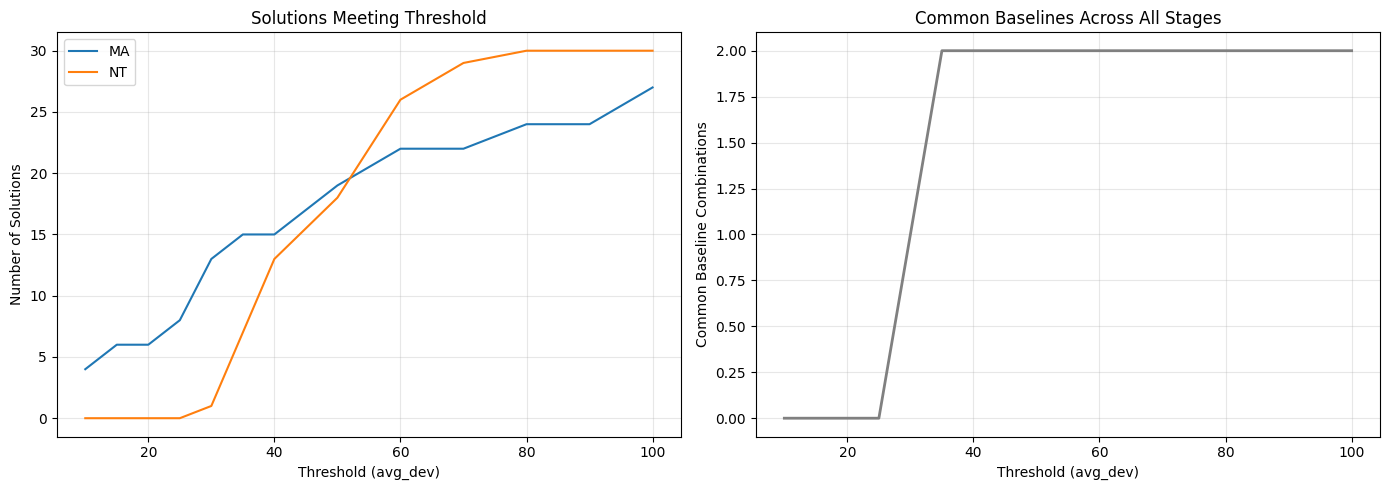

Minimum threshold with common baselines: 30


In [272]:
import matplotlib.pyplot as plt
import pandas as pd

# Define baseline_params 
baseline_params = ['param_n_fert_base',	'param_p_fert_base','param_phu_wheat']

# Test different thresholds
thresholds = [10, 15, 20, 25, 30, 35, 40, 50, 60, 70, 80, 90, 100]

results = []
for thresh in thresholds:
    # filter by threshold
    # cc_count = len(cc_gs_subset[cc_gs_subset['avg_dev'] < thresh])
    ma_count = len(ma_gs_subset[ma_gs_subset['avg_dev'] < thresh])
    nt_count = len(nt_gs_subset[nt_gs_subset['avg_dev'] < thresh])
    
    # find common baselines at this threshold
    # cc_accept_temp = cc_gs_subset[cc_gs_subset['avg_dev'] < thresh]
    ma_accept_temp = ma_gs_subset[ma_gs_subset['avg_dev'] < thresh]
    nt_accept_temp = nt_gs_subset[nt_gs_subset['avg_dev'] < thresh]
    
    # cc_base = set(cc_accept_temp[baseline_params].apply(tuple, axis=1))
    ma_base = set(ma_accept_temp[baseline_params].apply(tuple, axis=1))
    nt_base = set(nt_accept_temp[baseline_params].apply(tuple, axis=1))
    
    common = ma_base & nt_base  # & cc_base
    
    results.append({
        'threshold': thresh,
        # 'cc_solutions': cc_count,
        'ma_solutions': ma_count,
        'nt_solutions': nt_count,
        'common_baselines': len(common)
    })

# Convert to dataframe
thresh_df = pd.DataFrame(results)
print(thresh_df)

# plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Solutions per stage
# axes[0].plot(thresh_df['threshold'], thresh_df['cc_solutions'], label='CC')
axes[0].plot(thresh_df['threshold'], thresh_df['ma_solutions'], label='MA')
axes[0].plot(thresh_df['threshold'], thresh_df['nt_solutions'], label='NT')
axes[0].set_xlabel('Threshold (avg_dev)')
axes[0].set_ylabel('Number of Solutions')
axes[0].set_title('Solutions Meeting Threshold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Common baselines
axes[1].plot(thresh_df['threshold'], thresh_df['common_baselines'], color='grey', linewidth=2)
axes[1].set_xlabel('Threshold (avg_dev)')
axes[1].set_ylabel('Common Baseline Combinations')
axes[1].set_title('Common Baselines Across All Stages')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('threshold_analysis.png', dpi=300)
plt.show()

# Recommend threshold
first_common = thresh_df[thresh_df['common_baselines'] > 0]['threshold'].min()
print(f"Minimum threshold with common baselines: {first_common}")

good_common = thresh_df[thresh_df['common_baselines'] >= 5]['threshold'].min() if len(thresh_df[thresh_df['common_baselines'] >= 5]) > 0 else None
if good_common:
    print(f"Threshold with 5+ common baselines: {good_common}")

## Filter all combinations

In [ ]:
import pandas as pd
import numpy as np

out_dir = # path to output csv

# Step 1: calculate average deviation for each stage
ma_gs_subset['avg_dev'] = ma_gs_subset[list(objectives_ma.keys())].mean(axis=1)
nt_gs_subset['avg_dev'] = nt_gs_subset[list(objectives_nt.keys())].mean(axis=1)

# Step 2: Filter solutions
threshold = 35
ma_accept = ma_gs_subset[(ma_gs_subset['avg_dev'] < threshold)]
nt_accept = nt_gs_subset[(nt_gs_subset['avg_dev'] < threshold)]

print(f"Acceptable Solutions: MA={len(ma_accept)}, NT={len(nt_accept)}")

# Step 3: Find common baselines
baseline_params = ['param_n_fert_base', 'param_p_fert_base', 'param_phu_wheat']
ma_baselines = set(ma_accept[baseline_params].apply(tuple, axis=1))
nt_baselines = set(nt_accept[baseline_params].apply(tuple, axis=1))
common_baselines = nt_baselines & ma_baselines

print(f"Common baselines: {len(common_baselines)}")

# Step 4: Get best solution for each common baseline
results = []
for baseline in common_baselines:
    n, p, phu = baseline

    ma_best = ma_accept[(ma_accept['param_n_fert_base']==n) & (ma_accept['param_p_fert_base']==p) & (ma_accept['param_phu_wheat']==phu)].nsmallest(1, 'avg_dev').iloc[0]
    nt_best = nt_accept[(nt_accept['param_n_fert_base']==n) & (nt_accept['param_p_fert_base']==p) & (nt_accept['param_phu_wheat']==phu)].nsmallest(1, 'avg_dev').iloc[0]

    # Create row
    row = {'param_n_fert_base': n, 'param_p_fert_base': p, 'param_phu_wheat': phu}

    # Add all columns from each stage with suffixes
    for col in ma_best.index:
        if col not in baseline_params:
            row[f'{col}_ma'] = ma_best[col]

    for col in nt_best.index:
        if col not in baseline_params:
            row[f'{col}_nt'] = nt_best[col]

    results.append(row)

# Create final dataframe
final = pd.DataFrame(results)
print("Columns in final:")
print([col for col in final.columns if 'avg_dev' in col])
final['avg_dev_overall'] = final[['avg_dev_ma', 'avg_dev_nt']].mean(axis=1)
final = final.sort_values('avg_dev_overall')

print(f"\n{len(final)} common baseline combinations")

final.to_csv(out_dir, index=False)


## BONUS: MA Baseline
Use this if MA is manure incorporation (application not included) so BMP has its own baseline

In [ ]:
import pandas as pd
import numpy as np

# CONFIGURATION

INPUT_CSV  = # edit
OUTPUT_CSV = # edit


# Regional targets for base_WYLD_per and base_ET_per (percentage points)
ET_TARGETS = {
    "a":  52,  
    "p":  32,
    "vr": 50,
    "cp": 36,
}

WYLD_TARGETS = {
    "a":  48,  # fill in
    "p":  68,
    "vr": 49,
    "cp": 64,
}

# Alfalfa-specific overrides (leave as None to fall back to regional value)
WYLD_TARGETS_ALFALFA = {
    "a":  49,
    "p":  70,
    "vr": 50,
    "cp": 65,
}

ET_TARGETS_ALFALFA = {
    "a":  51,
    "p":  30,
    "vr": 50,
    "cp": 35,
}


# N removal target: 8% for all region-crop combinations
N_TARGET = 8.0

# P removal targets: range for A/P/VR, single value for CP
P_RANGE = (12.0, 24.0)   # applies to a, p, vr
P_CP    = 14.0            # applies to cp

# LOAD

df = pd.read_csv(INPUT_CSV)

# Filter out negative MUSLE removal efficiencies before scoring
df = df[df["ma_MUSLEt_ha"] >= 0].copy()

# OPTIMIZATION SCORING

PARAMS     = ["phu", "manure_kg_ha", "fert_reduction", "pec", "n_fert", "p_fert"]
OBJECTIVES = ["ma_Nkg_ha", "ma_Pkg_ha", "ma_MUSLEt_ha",
              "base_WYLD_per", "base_ET_per", "base_WB_error", "ma_Crop_Yield"]

def norm(col):
    mn, mx = col.min(), col.max()
    if mx == mn:
        return pd.Series(np.zeros(len(col)), index=col.index)
    return (col - mn) / (mx - mn)

def p_penalty(val, region):
    if region == "cp":
        return abs(val - P_CP)
    else:
        lo, hi = P_RANGE
        return max(0.0, lo - val, val - hi)

results = []

for (region, crop), group in df.groupby(["region", "crop"]):
    group = group.copy()

    # Resolve WYLD and ET targets (alfalfa override if set)
    if crop == "alfalfa":
        wyld_target = WYLD_TARGETS_ALFALFA[region] or WYLD_TARGETS[region]
        et_target   = ET_TARGETS_ALFALFA[region]   or ET_TARGETS[region]
    else:
        wyld_target = WYLD_TARGETS[region]
        et_target   = ET_TARGETS[region]

    # Raw penalties
    group["dev_N"]     = (group["ma_Nkg_ha"]    - N_TARGET).abs()
    group["dev_P"]     = group["ma_Pkg_ha"].apply(lambda v: p_penalty(v, region))
    group["dev_MUSLE"] = group["ma_MUSLEt_ha"].abs()
    group["dev_WYLD"]  = (group["base_WYLD_per"] - wyld_target).abs() / abs(wyld_target)
    group["dev_ET"]    = (group["base_ET_per"]   - et_target).abs()   / abs(et_target)
    group["dev_WB"]    = group["base_WB_error"].abs()

    max_yield          = group["ma_Crop_Yield"].max()
    group["dev_Yield"] = max_yield - group["ma_Crop_Yield"]

    # Normalize each penalty to [0, 1] within this group and average
    penalty_cols = ["dev_N", "dev_P", "dev_MUSLE", "dev_WYLD", "dev_ET", "dev_WB", "dev_Yield"]
    for c in penalty_cols:
        group[c + "_norm"] = norm(group[c])

    group["total_score"] = group[[c + "_norm" for c in penalty_cols]].mean(axis=1)

    results.append(group)

scored = pd.concat(results, ignore_index=True)

# OUTPUT

best = (scored.sort_values("total_score")
              .groupby(["region", "crop"], as_index=False)
              .first())

out_cols = (["region", "crop"] + PARAMS +
            ["dev_N", "dev_P", "dev_MUSLE", "dev_WYLD", "dev_ET", "dev_WB", "dev_Yield",
             "total_score"] + OBJECTIVES)

best[out_cols].to_csv(OUTPUT_CSV, index=False)
print(f"Done. Results saved to {OUTPUT_CSV}")
print(best[["region", "crop", "total_score"] + PARAMS].to_string(index=False))

Done. Results saved to /Users/mayastruzak/Library/CloudStorage/Box-Box/cbw-ag-modeling-box/results/optimization/5-29-ma/best_params_scored.csv
region    crop  total_score  phu  manure_kg_ha  fert_reduction  pec    n_fert  p_fert
     a alfalfa     0.222460 1550         428.3            0.25 0.75   1.33500  7.7100
     a    corn     0.326337 2250        3856.9            0.90 0.95  14.14200  1.9550
     a     soy     0.183547 2000        2973.0            0.90 0.80   0.49700  1.9820
     a   wheat     0.082439 1550         344.9            0.10 0.75 102.44700 22.2300
    cp alfalfa     0.284840 1150        1345.5            0.90 0.70   0.31000  0.8970
    cp    corn     0.135193 1250         452.7            0.10 0.60 134.45100 17.5050
    cp     soy     0.261101 1250        1648.8            0.75 1.00   0.80500  3.2975
    cp   wheat     0.166090 1150         395.1            0.10 0.75 117.33300 37.5390
     p alfalfa     0.173193  900        1157.5            0.75 0.65   0.71000  2.31